In [2]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
## import MLPClassifier
from sklearn.neural_network import MLPClassifier
## accuracy_score
from sklearn.metrics import accuracy_score
RANDOM_STATE = 42

In [3]:
# usa make_moon para crear dos dataset intricados con 500 instancias cada uno

X_moon, y_moon = make_moons(n_samples=500, noise=0.1, random_state=RANDOM_STATE)

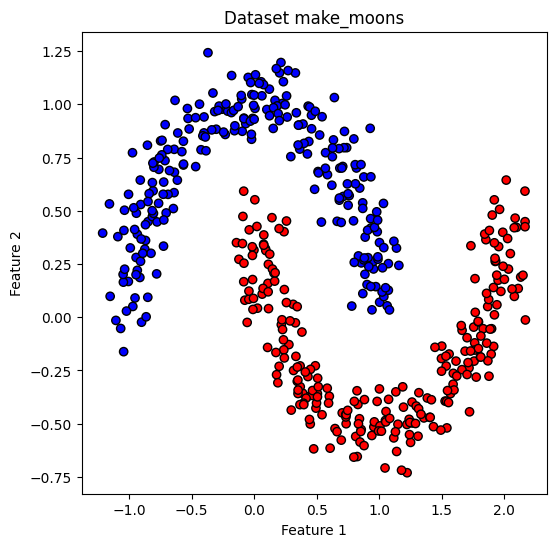

In [4]:
# graficamos el dataset con colores según la clase (rojo para clase 0, azul para clase 1)

plt.figure(figsize=(6, 6))
plt.scatter(X_moon[:, 0], X_moon[:, 1], c=y_moon, cmap='bwr', edgecolor='k')
plt.title('Dataset make_moons')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
#plt.grid()
plt.show()



In [10]:
# split del dataset en entrenamiento y prueba
from sklearn.model_selection import train_test_split
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_moon, y_moon, test_size=0.2, random_state=RANDOM_STATE)

Precisión en make_moons: 0.97


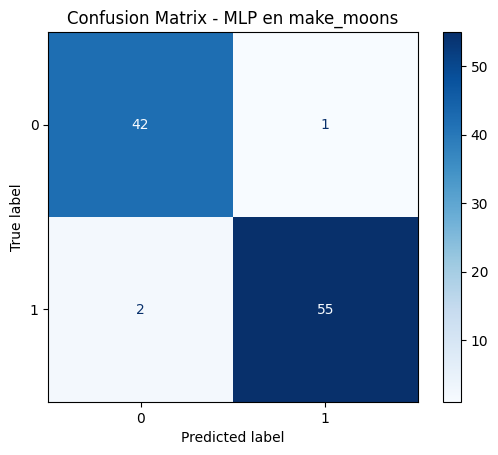

In [8]:
## definir Architectua de la red neuronal con sklearn usando 10 neuronas en la capa oculta y función de activación ReLU
#import numpy as np


# crear el clasificador con 10 neuronas en la capa oculta y función de activación ReLU
clf = MLPClassifier(hidden_layer_sizes=(100,100,100), activation='relu', random_state=RANDOM_STATE, max_iter=100000, early_stopping=True, validation_fraction=0.1)

# entrenar el modelo con el dataset make_moons con los splits de entrenamiento y prueba definidos anteriormente
clf.fit(X_train_m, y_train_m)
# predecir las clases del set de prueba y calcular la precisión
y_pred_m = clf.predict(X_test_m)
acc = accuracy_score(y_test_m, y_pred_m)
print(f'Precisión en make_moons: {acc:.2f}')

# confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test_m, y_pred_m)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - MLP en make_moons')
plt.show()




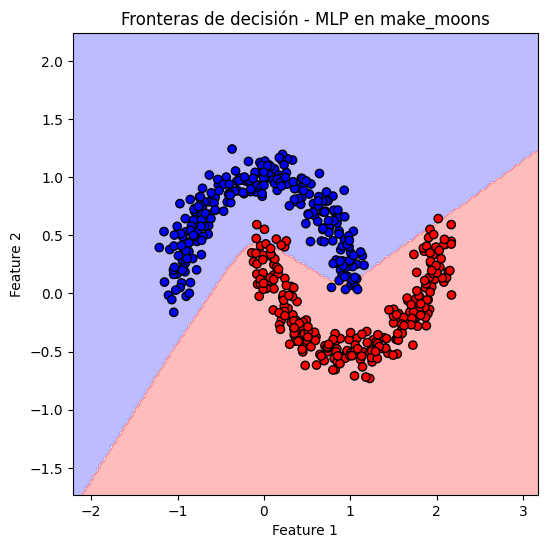

In [9]:
# plot fronteras de desicion

import numpy as np
# crear una malla de puntos para evaluar el modelo
x_min, x_max = X_moon[:, 0].min() - 1, X_moon[:, 0].max() + 1
y_min, y_max = X_moon[:, 1].min() - 1, X_moon[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape) # graficar las fronteras de decisión
plt.figure(figsize=(6, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='bwr')
plt.scatter(X_moon[:, 0], X_moon[:, 1], c=y_moon, cmap='bwr', edgecolor='k')
plt.title('Fronteras de decisión - MLP en make_moons')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()  